In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [96]:
df = pd.read_csv("PATH/f1_pitstops_2018_2024.csv", encoding='latin1', sep=';')
df.head()


,Season,Round,Circuit,Driver,Constructor,Laps,Position,TotalPitStops,AvgPitStopTime,Race Name,...,Tire Usage Aggression,Fast Lap Attempts,Position Changes,Driver Aggression Score,Abbreviation,Stint,Tire Compound,Stint Length,Pit_Lap,Pit_Time
0,2018,1.0,Albert Park Grand Prix Circuit,Sebastian Vettel,Ferrari,58.0,1.0,1.0,21.787,Australian Grand Prix,...,0.017241,4.476.881.994.581.150,0.000000,6.755.002.600.299.170,VET,1.0,ULTRASOFT,25.0,26.0,21.787
1,2018,1.0,Albert Park Grand Prix Circuit,Sebastian Vettel,Ferrari,58.0,1.0,1.0,21.787,Australian Grand Prix,...,0.017241,4.476.881.994.581.150,0.000000,6.755.002.600.299.170,VET,2.0,SOFT,32.0,NaN,Final Stint
2,2018,1.0,Albert Park Grand Prix Circuit,Lewis Hamilton,Mercedes,58.0,2.0,1.0,21.821,Australian Grand Prix,...,0.017241,4.473.481.995,0.043478,6.754.253.782.551.250,HAM,1.0,ULTRASOFT,17.0,19.0,21.821
3,2018,1.0,Albert Park Grand Prix Circuit,Lewis Hamilton,Mercedes,58.0,2.0,1.0,21.821,Australian Grand Prix,...,0.017241,4.473.481.995,0.043478,6.754.253.782.551.250,HAM,2.0,SOFT,39.0,NaN,Final Stint
4,2018,1.0,Albert Park Grand Prix Circuit,Kimi Raikonnen,Ferrari,58.0,3.0,1.0,21.421,Australian Grand Prix,...,0.017241,4.513.481.994.581.150,0.086957,6.818.562.124.342.590,RAI,1.0,ULTRASOFT,17.0,18.0,21.421


In [108]:
# Ensure Pit_Time is numeric
df['Pit_Time'] = pd.to_numeric(df['Pit_Time'], errors='coerce')
df = df.dropna(subset=['Pit_Time'])

In [110]:
# Categorize pit stop durations
def categorize_pit_time(x):
    if x < 30:
        return 'Usual'
    elif 30 <= x <= 60:
        return 'Unusual'
    else:
        return 'Exception'

df['PitStop_Category'] = df['Pit_Time'].apply(categorize_pit_time)

# Filter only 'Usual' pit stops for regression
df_usual = df[df['PitStop_Category'] == 'Usual'].copy()

# Optional: Limit constructors to top 5 to reduce sparsity
top_teams = df_usual['Constructor'].value_counts().nlargest(5).index
df_usual['Constructor'] = df_usual['Constructor'].apply(lambda x: x if x in top_teams else 'Other')

# Select relevant features
features = ['Constructor', 'Tire Compound', 'Air_Temp_C', 'Track_Temp_C']
df_usual = df_usual.dropna(subset=features)

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df_usual[features], drop_first=True)

# Add target
df_encoded['Pit_Time'] = df_usual['Pit_Time']

In [112]:
X = df_encoded.drop('Pit_Time', axis=1)
y = df_encoded['Pit_Time']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R² Score: 0.7402961111667633
RMSE: 1.4609561506556905


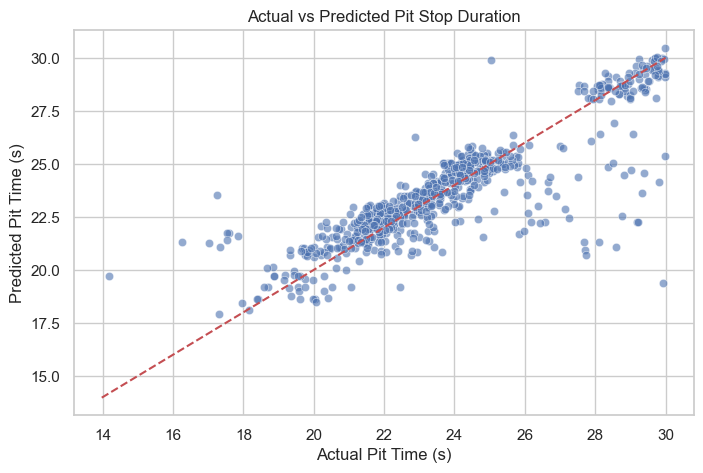

In [114]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual Pit Time (s)")
plt.ylabel("Predicted Pit Time (s)")
plt.title("Actual vs Predicted Pit Stop Duration")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # ideal line
plt.grid(True)
plt.show()


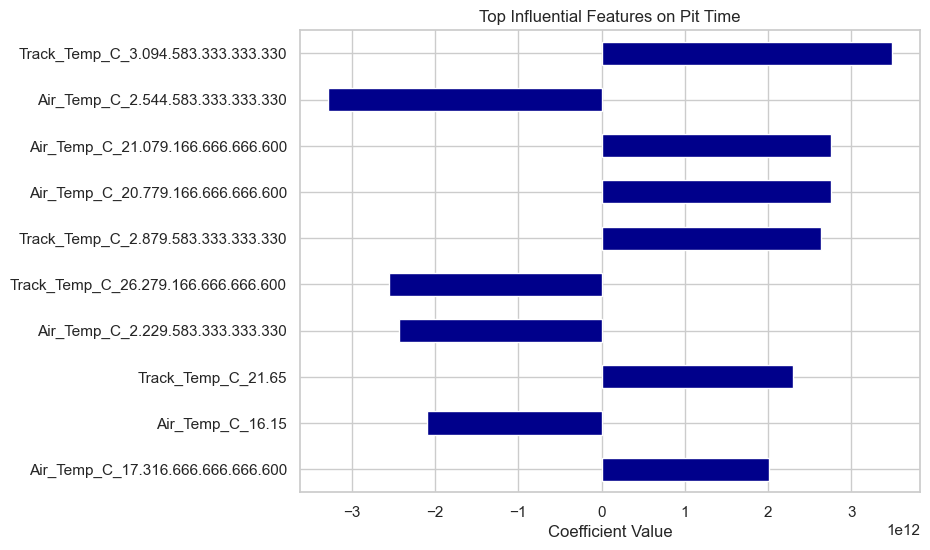

In [116]:
#Feature importance

coeffs = pd.Series(model.coef_, index=X.columns)
top_coeffs = coeffs.sort_values(key=abs, ascending=False).head(10)

top_coeffs.plot(kind='barh', figsize=(8,6), color='darkblue')
plt.title("Top Influential Features on Pit Time")
plt.xlabel("Coefficient Value")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()
